In [49]:
import itertools as iter

import awkward as ak

import dask
import dask_awkward as dak
import hist.dask as hda
import matplotlib.pyplot as plt

# import numba
import numpy as np
import uproot

# import vector as vec
from coffea.analysis_tools import PackedSelection
from coffea.nanoevents import NanoEventsFactory, ScoutingNanoAODSchema
# from hist import Hist


In [2]:
from coffea.lookup_tools import extractor
from coffea.jetmet_tools import FactorizedJetCorrector, JetCorrectionUncertainty
from coffea.jetmet_tools import JECStack, CorrectedJetsFactory

In [3]:
file_list = [line.strip('\n') for line in open("filelists/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] # + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0002.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

ScoutingNanoAODSchema.warn_missing_crossrefs = False

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[10:11]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "HadronicTops"},
).events()

events = small_events[0:10_000]
#ak.num(small_events, axis=0).compute()

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [10]:
events.GenPart.genPartIdxMother.compute()

<Array [[-1, -1, 0, ..., 106, 106, 113], ...] type='10000 * var * int16[par...'>

In [52]:
def apply_JEC_MC(ev, name, type):
    ext = extractor()
    ext.add_weight_sets(
        [
            "* * corrections/" + name + "/" + name + "_L1FastJet_AK4PF" + type + ".txt",
            "* * corrections/" + name + "/" + name + "_L2Relative_AK4PF" + type + ".txt",
            "* * corrections/" + name + "/" + name + "_L3Absolute_AK4PF" + type + ".txt",
            "* * corrections/" + name + "/" + name + "_L2L3Residual_AK4PF" + type + ".txt",
            #"* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi.junc.txt",
        ],
    )
    ext.finalize()

    jec_stack_names = [
        name + "_L1FastJet_AK4PF"+ type,
        name + "_L2Relative_AK4PF"+ type,
        name + "_L3Absolute_AK4PF"+ type,
        name + "_L2L3Residual_AK4P"+ type,
        #"Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi",
    ]

    evaluator = ext.make_evaluator()
    jec_inputs = {name: evaluator[name] for name in jec_stack_names}
    jec_stack = JECStack(jec_inputs)

    name_map = jec_stack.blank_name_map
    name_map["JetPt"] = "pt"
    name_map["JetMass"] = "mass"
    name_map["JetEta"] = "eta"
    name_map["JetA"] = "area"

    jets = ev.ScoutingJet

    jets["pt_raw"] = jets["pt"]
    jets["mass_raw"] = jets["mass"]
    jets["rho"] = ak.broadcast_arrays(ev.ScoutingRho, jets.pt)[0]
    name_map["ptGenJet"] = "pt_gen"
    name_map["ptRaw"] = "pt_raw"
    name_map["massRaw"] = "mass_raw"
    name_map["Rho"] = "rho"

    jet_factory = CorrectedJetsFactory(name_map, jec_stack)

    return jet_factory.build(jets)


In [56]:
events["ScoutingJet_corr_chs"] = apply_JEC_MC(events, "Summer22EE_22Sep2023_V2_MC", "Puppi")
events["ScoutingJet_corr_puppi"] = apply_JEC_MC(events, "Summer22EE_22Sep2023_V2_MC", "Puppi")

In [57]:
truth = events.GenPart[
            (abs(events.GenPart.pdgId) == 24)
              & ( events.GenPart.hasFlags(["isLastCopy","isPrompt"]))
              ]

w_to_jets_cut =(
    (abs(truth.distinctChildren[:,:,0].pdgId) == 1)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 2)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 3)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)
    )

w_truth = truth[w_to_jets_cut]


good_events = events[(ak.num(w_truth, axis=1) > 1)]

In [58]:
w_truth = w_truth[ak.num(w_truth, axis=1) > 1]
w_truth_1 = w_truth[:,0]
w_truth_2 = w_truth[:,1]

truth_b = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]))
    & ((good_events.GenPart.distinctParentIdxG == w_truth_1.distinctParentIdxG)
    | (good_events.GenPart.distinctParentIdxG == w_truth_2.distinctParentIdxG))
    ]

good_events = good_events[
    (ak.num(truth_b, axis=1) > 1)
    & (ak.num(w_truth_1.distinctChildren, axis=1) > 1)
    & (ak.num(w_truth_2.distinctChildren, axis=1) > 1)
    ]

In [15]:
ak.num(good_events,axis=0).compute()

9888

In [59]:
truth = good_events.GenPart[(abs(good_events.GenPart.pdgId) == 24) & ( good_events.GenPart.hasFlags(["isLastCopy","isPrompt"]))]

w_to_jets_cut = (
    (abs(truth.distinctChildren[:,:,0].pdgId) == 1)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 2)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 3)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)
    )
w_truth = truth[w_to_jets_cut]
w_truth = w_truth[ak.num(w_truth, axis=1) > 1]
w_truth_1 = w_truth[:,0]
w_truth_2 = w_truth[:,1]
w_jets_truth_1 = w_truth_1.distinctChildren
w_jets_truth_2 = w_truth_2.distinctChildren

truth_b1_temp = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]) )
    & (good_events.GenPart.distinctParentIdxG == w_truth_1.distinctParentIdxG)
    ]

truth_b2_temp = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]) )
    & (good_events.GenPart.distinctParentIdxG == w_truth_2.distinctParentIdxG)
    ]

truth_b1 = truth_b1_temp[:,0]
truth_b2 = truth_b2_temp[:,1]
jet1 = w_jets_truth_1[:,0]
jet2 = w_jets_truth_1[:,1]
jet3 = w_jets_truth_2[:,0]
jet4 = w_jets_truth_2[:,1]

In [19]:
print(ak.num(truth_b1,axis=0).compute())
print(ak.num(truth_b2,axis=0).compute())
print(ak.num(jet1,axis=0).compute())
print(ak.num(jet2,axis=0).compute())
print(ak.num(jet3,axis=0).compute())
print(ak.num(jet4,axis=0).compute())

9888
9888
9888
9888
9888
9888


In [26]:
(truth_b1 + jet1 + jet2).mass[:,0].compute()

<Array [151, 172, 156, 172, ..., 171, 142, 165, 113] type='9888 * ?float32'>

(array([5.700e+01, 8.100e+01, 1.160e+02, 9.500e+01, 1.350e+02, 1.780e+02,
        1.530e+02, 2.220e+02, 2.900e+02, 3.200e+02, 4.570e+02, 4.930e+02,
        6.580e+02, 8.660e+02, 1.108e+03, 1.277e+03, 2.486e+03, 5.890e+02,
        7.300e+01, 2.300e+01, 1.800e+01, 5.000e+00, 1.400e+01, 5.000e+00,
        7.000e+00, 7.000e+00, 3.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00]),
 array([100.        , 104.2857132 , 108.57142639, 112.85713959,
        117.14286041, 121.42857361, 125.7142868 , 130.        ,
        134.28572083, 138.57142639, 142.85714722, 147.14285278,
        151.42857361, 155.71427917, 160.        , 164.28572083,
        168.57142639, 172.85714722, 177.14285278, 181.42857361,
        185.71427917, 190.        , 194.28572083, 198.57142639,
        202.85714722, 207.14285278, 211.42857361, 215.71427917,
        220.        , 224.28572083, 228.57142639, 232.85714722,
        237.14285278, 241.42857361, 245.71427917, 250

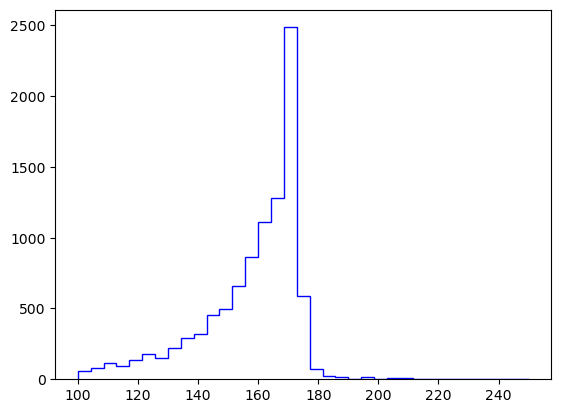

In [28]:
plt.hist(
    (truth_b1 + jet1 + jet2).m[:,0].compute(),
    bins=35,
    range=(100,250),
    histtype="step",
    color="blue",
    label="uncorrected",
         )

In [60]:
uncorr_b = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet),axis=1)
        ]
uncorr_j1 = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJet),axis=1)
        ]
uncorr_j2 = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJet),axis=1)
        ]

corr_b = good_events.ScoutingJets_corr[
        ak.local_index(good_events.ScoutingJets_corr,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJets_corr),axis=1)
        ]
corr_j1 = good_events.ScoutingJets_corr[
        ak.local_index(good_events.ScoutingJets_corr,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJets_corr),axis=1)
        ]
corr_j2 = good_events.ScoutingJets_corr[
        ak.local_index(good_events.ScoutingJets_corr,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJets_corr),axis=1)
        ]

corr_b_chs = good_events.ScoutingJets_corr_chs[
        ak.local_index(good_events.ScoutingJets_corr_chs,axis=1)
        == ak.argmin(truth_b1.delta_r(good_events.ScoutingJets_corr_chs),axis=1)
        ]
corr_j1_chs = good_events.ScoutingJets_corr_chs[
        ak.local_index(good_events.ScoutingJets_corr_chs,axis=1)
        == ak.argmin(jet1.delta_r(good_events.ScoutingJets_corr_chs),axis=1)
        ]
corr_j2_chs = good_events.ScoutingJets_corr_chs[
        ak.local_index(good_events.ScoutingJets_corr_chs,axis=1)
        == ak.argmin(jet2.delta_r(good_events.ScoutingJets_corr_chs),axis=1)
        ]

In [44]:
(uncorr_b + uncorr_j1 + uncorr_j2).m.compute()

<Array [[122], [216], [142], ..., [142], [164]] type='9888 * option[var * f...'>

In [45]:
(corr_b + corr_j1 + corr_j2).m.compute()

<Array [[75.9], [39.6], ..., [65.4], [57.6]] type='9888 * option[var * floa...'>

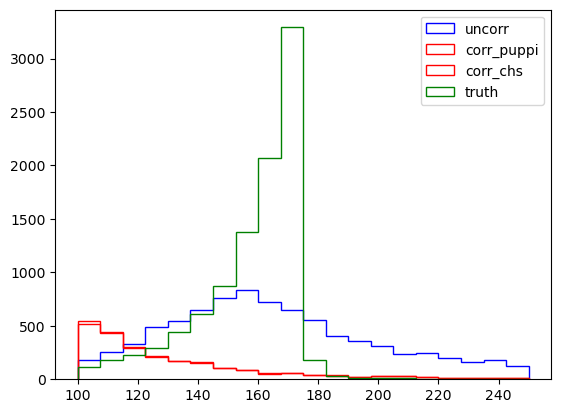

In [ ]:
plt.hist(
    (uncorr_b + uncorr_j1 + uncorr_j2).m[:,0].compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="blue",
    label="uncorr",
         )
plt.hist(
    (corr_b + corr_j1 + corr_j2).m[:,0].compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="red",
    label="corr_puppi",
         )
plt.hist(
    (corr_b_chs + corr_j1_chs + corr_j2_chs).m[:,0].compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="",
    label="corr_chs",
         )
plt.hist(
    (truth_b1 + jet1 + jet2).m.compute(),
    bins=20,
    range=(100,250),
    histtype="step",
    color="green",
    label="truth",
         )

plt.legend()

In [29]:
arr = []
for truth_jet in [jet1,jet2,jet3,jet4,truth_b1,truth_b2]:
    temp_cand = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(truth_jet.delta_r(good_events.ScoutingJet),axis=1)
        ].pt
    temp_truth = truth_jet.pt
    arr.append(np.array(ak.flatten((temp_cand - temp_truth).compute())))

print(arr)

arr_corr = []
for truth_jet in [jet1,jet2,jet3,jet4,truth_b1,truth_b2]:
    temp_cand = good_events.ScoutingJets_corr[
        ak.local_index(good_events.ScoutingJets_corr,axis=1)
        == ak.argmin(truth_jet.delta_r(good_events.ScoutingJets_corr),axis=1)
        ].pt
    temp_truth = truth_jet.pt
    arr_corr.append(np.array(ak.flatten((temp_cand - temp_truth).compute())))

arr_corr

[array([ -8.845844 ,   6.9864388, -11.928993 , ...,  -4.258896 ,
        -6.266327 ,   9.8263235], dtype=float32), array([-12.247978 ,  38.308952 ,  -7.263218 , ...,  -2.9099274,
       -14.002235 ,  -8.101898 ], dtype=float32), array([ -8.719393 ,  -9.33577  ,   4.9998856, ..., -23.592533 ,
         6.792164 ,   7.661377 ], dtype=float32), array([-15.810738 ,  11.571274 , -19.76442  , ...,   9.015128 ,
        -1.3461075,  -5.2185516], dtype=float32), array([-7.2494392, 15.618103 , -3.9788857, ...,  6.769802 , -4.325287 ,
       18.451698 ], dtype=float32), array([-16.559475  ,  -1.7469101 ,   8.701611  , ...,   7.2528076 ,
         0.53824997, -36.19344   ], dtype=float32)]


[array([-1.0178413 , 21.275597  , -7.360588  , ...,  0.55132294,
        -3.9986992 , 11.542382  ], dtype=float32),
 array([ -8.171909  ,  64.24367   ,  -0.38235855, ...,  -0.15448761,
        -11.929043  ,   0.9470215 ], dtype=float32),
 array([ -6.993147 ,  -0.9332504,   8.8613205, ..., -19.025818 ,
         19.57677  ,  13.359486 ], dtype=float32),
 array([ -8.95797  ,  19.761257 , -17.375805 , ...,  20.653355 ,
          8.190323 ,  -2.0833893], dtype=float32),
 array([-4.387722  , 35.065407  , -0.07299805, ..., 16.270338  ,
         0.92059326, 20.576126  ], dtype=float32),
 array([-13.611286 ,   0.9168167,  13.749561 , ...,  10.052238 ,
          3.0060654, -31.188564 ], dtype=float32)]

Text(0.5, 0, 'GenJet_pT - matched_ScoutingJet_pT')

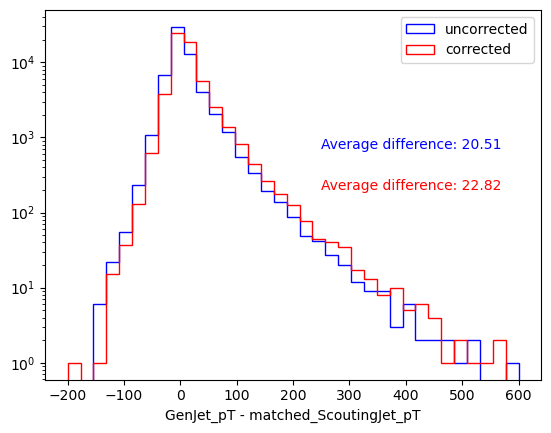

In [49]:
plt.hist(
    np.concatenate(arr),
    bins=35,
    range=(-200,600),
    histtype="step",
    color="blue",
    label="uncorrected",
         )
plt.hist(
    np.concatenate(arr_corr),
    bins=35,
    range=(-200,600),
    histtype="step",
    color="red",
    label="corrected",
         )

plt.legend()
plt.yscale("log")
plt.text(250,700,"Average difference: " + str(round(sum(abs(np.concatenate(arr)))/len(np.concatenate(arr)),2)),color="blue")
plt.text(250,200,"Average difference: " + str(round(sum(abs(np.concatenate(arr_corr)))/len(np.concatenate(arr_corr)),2)),color="red")
plt.xlabel("GenJet_pT - matched_ScoutingJet_pT")

Text(0.5, 0, 'abs(matched_ScoutingJet_pT/GenJet_pT - 1)')

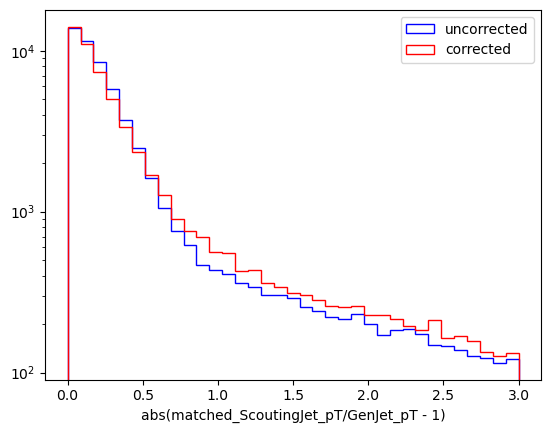

In [28]:
plt.hist(
    abs(np.concatenate(arr) - 1),
    bins=35,
    range=(0,3),
    histtype="step",
    color="blue",
    label="uncorrected",
         )
plt.hist(
    abs(np.concatenate(arr_corr) - 1),
    bins=35,
    range=(0,3),
    histtype="step",
    color="red",
    label="corrected",
         )

plt.legend()
plt.yscale("log")
plt.xlabel("abs(matched_ScoutingJet_pT/GenJet_pT - 1)")

In [21]:
exam = np.array([4,5,3,4,5])


In [24]:
sum(abs(np.concatenate(arr) - 1))

48803.395416677

In [25]:
sum(abs(np.concatenate(arr_corr) - 1))

57509.15446227789